# TP 1 — Pipeline Iris : solution commentée

Solution complète du [TP 1](./enonce.ipynb).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

## Exercice 1 — Exploration

In [2]:
iris = load_iris()
X, y = iris.data, iris.target
print("X shape  :", X.shape)
print("features :", iris.feature_names)
print("classes  :", list(iris.target_names))
print("counts   :", np.bincount(y))

df = pd.DataFrame(X, columns=iris.feature_names)
df["label"] = [iris.target_names[i] for i in y]
df.describe()

X shape  : (150, 4)
features : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
classes  : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
counts   : [50 50 50]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## Exercice 2 — Split train/test

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)
print("train :", X_train.shape, "  classes:", np.bincount(y_train))
print("test  :", X_test.shape, "  classes:", np.bincount(y_test))

train : (120, 4)   classes: [40 40 40]
test  : (30, 4)   classes: [10 10 10]


## Exercice 3 — k-NN

train acc = 0.958
test  acc = 1.000

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



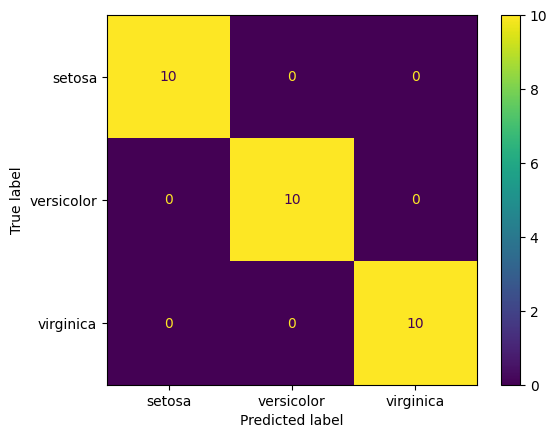

In [4]:
clf = KNeighborsClassifier(n_neighbors=5)
clf.fit(X_train, y_train)

print(f"train acc = {clf.score(X_train, y_train):.3f}")
print(f"test  acc = {clf.score(X_test, y_test):.3f}")
print()
print(classification_report(y_test, clf.predict(X_test), target_names=iris.target_names))

ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, display_labels=iris.target_names)

## Exercice 4 — Sensibilité à k

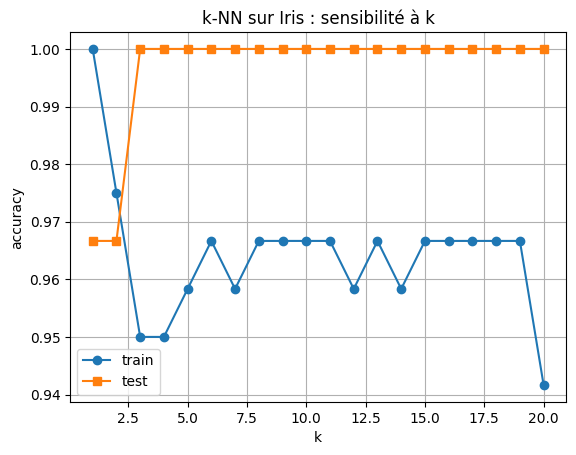

In [5]:
ks = range(1, 21)
tr, te = [], []
for k in ks:
    m = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    tr.append(m.score(X_train, y_train))
    te.append(m.score(X_test, y_test))

plt.plot(ks, tr, "o-", label="train")
plt.plot(ks, te, "s-", label="test")
plt.xlabel("k")
plt.ylabel("accuracy")
plt.legend()
plt.title("k-NN sur Iris : sensibilité à k")
plt.grid(True)

**Discussion** : pour `k=1` l'accuracy train est de 100 % par construction (chaque point est son propre voisin) mais la généralisation est moins bonne. Au-delà d'une certaine valeur, l'accuracy test décroît car le modèle « moyenne » trop de voisins.